GitHub Repository: https://github.com/mariamekram/final-project

# DECI Level 3 — GitHub Machine Learning Repository Analytics

**End-to-End Data Analytics Project**

This notebook follows the required workflow:
**GitHub API → Data Collection → Pandas Cleaning → CSV → SQLite → SQL Analysis → Python Visualizations → Insights → GitHub → Ethics Reflection**

> The notebook is designed for Google Colab. Run the cells from top to bottom.


## 1. Setup

We install/import the main tools used in the project:
- `requests` for the GitHub API
- `pandas` for data preparation
- `matplotlib` and `seaborn` for visualization
- Python's built-in `sqlite3` for the database


In [1]:
!pip -q install requests pandas matplotlib seaborn

import requests
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print("Setup completed successfully.")


Setup completed successfully.


## 2. Collect real data from the GitHub API

We search for public repositories related to **Machine Learning**.

The collection uses the GitHub REST API and pagination. We collect repository-level fields such as stars, forks, issues, language, dates, size, and activity information.


In [2]:
import requests
import pandas as pd
import time

API_URL = "https://api.github.com/search/repositories"

QUERY = "machine learning in:name,description"
PER_PAGE = 50
PAGES = 5

headers = {
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "DECI-GitHub-Analytics-Project"
}

rows = []

for page in range(1, PAGES + 1):

    params = {
        "q": QUERY,
        "sort": "stars",
        "order": "desc",
        "per_page": PER_PAGE,
        "page": page
    }

    response = requests.get(
        API_URL,
        headers=headers,
        params=params,
        timeout=30
    )

    print("Status:", response.status_code)

    if response.status_code != 200:
        print(response.text)
        continue

    data = response.json()

    for repo in data.get("items", []):

        license_name = "Unknown"

        if repo.get("license") is not None:
            license_name = repo["license"].get("spdx_id", "Unknown")

        rows.append({
            "repo_id": repo.get("id"),
            "name": repo.get("name"),
            "full_name": repo.get("full_name"),
            "owner": repo.get("owner", {}).get("login"),
            "description": repo.get("description"),
            "language": repo.get("language"),
            "stars": repo.get("stargazers_count", 0),
            "forks": repo.get("forks_count", 0),
            "open_issues": repo.get("open_issues_count", 0),
            "watchers": repo.get("watchers_count", 0),
            "size_kb": repo.get("size", 0),
            "default_branch": repo.get("default_branch"),
            "created_at": repo.get("created_at"),
            "updated_at": repo.get("updated_at"),
            "pushed_at": repo.get("pushed_at"),
            "license": license_name,
            "is_fork": repo.get("fork", False),
            "is_archived": repo.get("archived", False),
            "html_url": repo.get("html_url")
        })

    print(f"Page {page}/{PAGES} completed")
    time.sleep(1)

df_raw = pd.DataFrame(rows)

print()
print("=" * 50)
print("DATA COLLECTION COMPLETED")
print("=" * 50)
print("Total repositories:", len(df_raw))

display(df_raw.head())

Status: 200
Page 1/5 completed
Status: 200
Page 2/5 completed
Status: 403
{"message":"API rate limit exceeded for 136.113.98.210. (But here's the good news: Authenticated requests get a higher rate limit. Check out the documentation for more details.)","documentation_url":"https://docs.github.com/rest/overview/resources-in-the-rest-api#rate-limiting"}

Status: 200
Page 4/5 completed
Status: 200
Page 5/5 completed

DATA COLLECTION COMPLETED
Total repositories: 200


,repo_id,name,full_name,owner,description,language,stars,forks,open_issues,watchers,size_kb,default_branch,created_at,updated_at,pushed_at,license,is_fork,is_archived,html_url
0,45717250,tensorflow,tensorflow/tensorflow,tensorflow,An Open Source Machine Learning Framework for Everyone,C++,198067,76200,2985,198067,1374565,master,2015-11-07T01:19:20Z,2026-08-30T17:58:09Z,2026-08-30T18:35:16Z,Apache-2.0,False,False,https://github.com/tensorflow/tensorflow
1,155220641,transformers,huggingface/transformers,huggingface,🤗 Transformers: the model-definition framework for state-of-the-art machine ...,Python,164636,34394,2402,164636,508377,main,2018-10-29T13:56:00Z,2026-08-30T17:33:32Z,2026-08-30T13:25:39Z,Apache-2.0,False,False,https://github.com/huggingface/transformers
2,343965132,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,"12 weeks, 26 lessons, 52 quizzes, classic Machine Learning for all",Jupyter Notebook,89935,22125,13,89935,2233917,main,2021-03-03T01:34:05Z,2026-08-30T17:57:42Z,2026-08-20T01:11:33Z,MIT,False,False,https://github.com/microsoft/ML-For-Beginners
3,145553672,funNLP,fighting41love/funNLP,fighting41love,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽取、邮箱抽取、中日文人名库、中文缩写库、拆字词典、词汇情感值...,Python,82773,15276,52,82773,174188,master,2018-08-21T11:20:39Z,2026-08-30T17:30:13Z,2024-05-10T07:38:24Z,Unknown,False,False,https://github.com/fighting41love/funNLP
4,21872392,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,"A curated list of awesome Machine Learning frameworks, libraries and software.",Python,74218,15636,30,74218,2683,master,2014-07-15T19:11:19Z,2026-08-30T17:50:59Z,2026-08-27T15:29:10Z,NOASSERTION,False,False,https://github.com/josephmisiti/awesome-machine-learning


## 3. Initial data inspection

Before cleaning, we inspect data types, missing values, and duplicates.


In [3]:
print("Dataset information:")
df_raw.info()

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate repository IDs:", df_raw["repo_id"].duplicated().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   repo_id         200 non-null    int64 
 1   name            200 non-null    object
 2   full_name       200 non-null    object
 3   owner           200 non-null    object
 4   description     195 non-null    object
 5   language        155 non-null    object
 6   stars           200 non-null    int64 
 7   forks           200 non-null    int64 
 8   open_issues     200 non-null    int64 
 9   watchers        200 non-null    int64 
 10  size_kb         200 non-null    int64 
 11  default_branch  200 non-null    object
 12  created_at      200 non-null    object
 13  updated_at      200 non-null    object
 14  pushed_at       200 non-null    object
 15  license         200 non-null    object
 16  is_fork         200 non-null    bool  
 17  is_archived     200 non-null    b

,missing_count
language,45
description,5
repo_id,0
full_name,0
name,0
owner,0
stars,0
forks,0
open_issues,0
watchers,0



Duplicate repository IDs: 0


## 4. Clean and prepare the dataset with Pandas

Cleaning steps:
1. Remove duplicate repositories.
2. Normalize date columns.
3. Fill categorical missing values with `Unknown`.
4. Fill numeric missing values with zero where appropriate.
5. Convert Boolean fields to consistent values.
6. Add useful derived columns such as repository age, activity recency, and engagement score.


In [4]:
df = df_raw.copy()

# Remove duplicate repositories
df = df.drop_duplicates(subset=["repo_id"]).copy()

# Convert date columns
date_cols = ["created_at", "updated_at", "pushed_at"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Clean categorical columns
for col in ["language", "license", "description", "owner", "default_branch"]:
    df[col] = df[col].fillna("Unknown")

# Clean numeric columns
numeric_cols = [
    "stars", "forks", "open_issues", "watchers", "size_kb"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Boolean cleanup
df["is_fork"] = df["is_fork"].fillna(False).astype(bool)
df["is_archived"] = df["is_archived"].fillna(False).astype(bool)

# Derived columns
now = pd.Timestamp.now(tz="UTC")

df["repo_age_years"] = (
    (now - df["created_at"]).dt.total_seconds() / (365.25 * 24 * 3600)
).clip(lower=0).round(2)

df["days_since_update"] = (
    (now - df["updated_at"]).dt.total_seconds() / (24 * 3600)
).clip(lower=0).round(0)

df["days_since_push"] = (
    (now - df["pushed_at"]).dt.total_seconds() / (24 * 3600)
).clip(lower=0).round(0)

# Simple engagement metric for analysis
df["engagement_score"] = (
    df["stars"] + 2 * df["forks"] + df["watchers"]
)

# Useful categorical activity label
df["activity_status"] = np.select(
    [
        df["days_since_push"] <= 30,
        df["days_since_push"] <= 180
    ],
    [
        "Very Active",
        "Recently Active"
    ],
    default="Less Active"
)

# Keep a clean column order
columns = [
    "repo_id", "name", "full_name", "owner", "description", "language",
    "stars", "forks", "open_issues", "watchers", "size_kb",
    "default_branch", "created_at", "updated_at", "pushed_at",
    "license", "is_fork", "is_archived", "repo_age_years",
    "days_since_update", "days_since_push", "engagement_score",
    "activity_status", "html_url"
]

df = df[columns]

print("Clean dataset shape:", df.shape)
display(df.head())


Clean dataset shape: (200, 24)


,repo_id,name,full_name,owner,description,language,stars,forks,open_issues,watchers,size_kb,default_branch,created_at,updated_at,pushed_at,license,is_fork,is_archived,repo_age_years,days_since_update,days_since_push,engagement_score,activity_status,html_url
0,45717250,tensorflow,tensorflow/tensorflow,tensorflow,An Open Source Machine Learning Framework for Everyone,C++,198067,76200,2985,198067,1374565,master,2015-11-07 01:19:20+00:00,2026-08-30 17:58:09+00:00,2026-08-30 18:35:16+00:00,Apache-2.0,False,False,10.81,0.0,0.0,548534,Very Active,https://github.com/tensorflow/tensorflow
1,155220641,transformers,huggingface/transformers,huggingface,🤗 Transformers: the model-definition framework for state-of-the-art machine ...,Python,164636,34394,2402,164636,508377,main,2018-10-29 13:56:00+00:00,2026-08-30 17:33:32+00:00,2026-08-30 13:25:39+00:00,Apache-2.0,False,False,7.84,0.0,0.0,398060,Very Active,https://github.com/huggingface/transformers
2,343965132,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,"12 weeks, 26 lessons, 52 quizzes, classic Machine Learning for all",Jupyter Notebook,89935,22125,13,89935,2233917,main,2021-03-03 01:34:05+00:00,2026-08-30 17:57:42+00:00,2026-08-20 01:11:33+00:00,MIT,False,False,5.49,0.0,11.0,224120,Very Active,https://github.com/microsoft/ML-For-Beginners
3,145553672,funNLP,fighting41love/funNLP,fighting41love,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽取、邮箱抽取、中日文人名库、中文缩写库、拆字词典、词汇情感值...,Python,82773,15276,52,82773,174188,master,2018-08-21 11:20:39+00:00,2026-08-30 17:30:13+00:00,2024-05-10 07:38:24+00:00,Unknown,False,False,8.03,0.0,842.0,196098,Less Active,https://github.com/fighting41love/funNLP
4,21872392,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,"A curated list of awesome Machine Learning frameworks, libraries and software.",Python,74218,15636,30,74218,2683,master,2014-07-15 19:11:19+00:00,2026-08-30 17:50:59+00:00,2026-08-27 15:29:10+00:00,NOASSERTION,False,False,12.13,0.0,3.0,179708,Very Active,https://github.com/josephmisiti/awesome-machine-learning


## 5. Save the prepared dataset as CSV

This creates the project deliverable required by the workflow.


In [5]:
CSV_PATH = "github_ml_repositories_clean.csv"

# SQLite/CSV-friendly date representation
df_csv = df.copy()
for col in date_cols:
    df_csv[col] = df_csv[col].dt.strftime("%Y-%m-%d %H:%M:%S")

df_csv.to_csv(CSV_PATH, index=False)

print(f"Saved: {CSV_PATH}")
print(f"Rows: {len(df_csv):,}")
print(f"Columns: {len(df_csv.columns)}")

display(df_csv.head())


Saved: github_ml_repositories_clean.csv
Rows: 200
Columns: 24


,repo_id,name,full_name,owner,description,language,stars,forks,open_issues,watchers,size_kb,default_branch,created_at,updated_at,pushed_at,license,is_fork,is_archived,repo_age_years,days_since_update,days_since_push,engagement_score,activity_status,html_url
0,45717250,tensorflow,tensorflow/tensorflow,tensorflow,An Open Source Machine Learning Framework for Everyone,C++,198067,76200,2985,198067,1374565,master,2015-11-07 01:19:20,2026-08-30 17:58:09,2026-08-30 18:35:16,Apache-2.0,False,False,10.81,0.0,0.0,548534,Very Active,https://github.com/tensorflow/tensorflow
1,155220641,transformers,huggingface/transformers,huggingface,🤗 Transformers: the model-definition framework for state-of-the-art machine ...,Python,164636,34394,2402,164636,508377,main,2018-10-29 13:56:00,2026-08-30 17:33:32,2026-08-30 13:25:39,Apache-2.0,False,False,7.84,0.0,0.0,398060,Very Active,https://github.com/huggingface/transformers
2,343965132,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,"12 weeks, 26 lessons, 52 quizzes, classic Machine Learning for all",Jupyter Notebook,89935,22125,13,89935,2233917,main,2021-03-03 01:34:05,2026-08-30 17:57:42,2026-08-20 01:11:33,MIT,False,False,5.49,0.0,11.0,224120,Very Active,https://github.com/microsoft/ML-For-Beginners
3,145553672,funNLP,fighting41love/funNLP,fighting41love,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽取、邮箱抽取、中日文人名库、中文缩写库、拆字词典、词汇情感值...,Python,82773,15276,52,82773,174188,master,2018-08-21 11:20:39,2026-08-30 17:30:13,2024-05-10 07:38:24,Unknown,False,False,8.03,0.0,842.0,196098,Less Active,https://github.com/fighting41love/funNLP
4,21872392,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,"A curated list of awesome Machine Learning frameworks, libraries and software.",Python,74218,15636,30,74218,2683,master,2014-07-15 19:11:19,2026-08-30 17:50:59,2026-08-27 15:29:10,NOASSERTION,False,False,12.13,0.0,3.0,179708,Very Active,https://github.com/josephmisiti/awesome-machine-learning


## 6. Create a SQLite database

The cleaned dataset is loaded into SQLite so that the analysis can be performed using SQL.


In [6]:
DB_PATH = "github_ml_analysis.sqlite"

conn = sqlite3.connect(DB_PATH)

# Store a clean analysis table
df_csv.to_sql(
    "repositories",
    conn,
    if_exists="replace",
    index=False
)

# Verify row count
row_count = pd.read_sql_query(
    "SELECT COUNT(*) AS total_repositories FROM repositories",
    conn
)

display(row_count)


,total_repositories
0,200


# 7. SQL Analysis

The following queries answer meaningful business/data questions about the GitHub Machine Learning repository ecosystem.


### Q1. Top 10 repositories by Stars

In [7]:
q1 = pd.read_sql_query(
    '''
    SELECT name, full_name, language, stars, forks, open_issues, html_url
    FROM repositories
    ORDER BY stars DESC
    LIMIT 10
    ''',
    conn
)
display(q1)


,name,full_name,language,stars,forks,open_issues,html_url
0,tensorflow,tensorflow/tensorflow,C++,198067,76200,2985,https://github.com/tensorflow/tensorflow
1,transformers,huggingface/transformers,Python,164636,34394,2402,https://github.com/huggingface/transformers
2,ML-For-Beginners,microsoft/ML-For-Beginners,Jupyter Notebook,89935,22125,13,https://github.com/microsoft/ML-For-Beginners
3,funNLP,fighting41love/funNLP,Python,82773,15276,52,https://github.com/fighting41love/funNLP
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,Python,74218,15636,30,https://github.com/josephmisiti/awesome-machine-learning
5,scikit-learn,scikit-learn/scikit-learn,Python,67103,27335,2136,https://github.com/scikit-learn/scikit-learn
6,gradio,gradio-app/gradio,Python,43438,3580,161,https://github.com/gradio-app/gradio
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26/500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Proj...,Unknown,36645,7478,68,https://github.com/ashishpatel26/500-AI-Machine-learning-Deep-learning-Compu...
8,C-Plus-Plus,TheAlgorithms/C-Plus-Plus,C++,34623,7854,25,https://github.com/TheAlgorithms/C-Plus-Plus
9,netron,lutzroeder/netron,JavaScript,33427,3176,18,https://github.com/lutzroeder/netron


### Q2. Most popular programming languages by repository count

In [8]:
q2 = pd.read_sql_query(
    '''
    SELECT
        language,
        COUNT(*) AS repository_count,
        ROUND(AVG(stars), 2) AS average_stars,
        SUM(stars) AS total_stars
    FROM repositories
    WHERE language <> 'Unknown'
    GROUP BY language
    ORDER BY repository_count DESC
    LIMIT 15
    ''',
    conn
)
display(q2)


,language,repository_count,average_stars,total_stars
0,Jupyter Notebook,52,8752.46,455128
1,Python,51,17214.96,877963
2,C++,17,23937.59,406939
3,HTML,8,5619.63,44957
4,JavaScript,6,12319.83,73919
5,Go,5,6986.80,34934
6,C#,4,9235.00,36940
7,TeX,2,6448.00,12896
8,Scala,2,8663.00,17326
9,Rust,1,4739.00,4739


### Q3. Languages with the highest average popularity

This helps distinguish languages that are common from languages whose repositories tend to receive more stars.


In [9]:
q3 = pd.read_sql_query(
    '''
    SELECT
        language,
        COUNT(*) AS repository_count,
        ROUND(AVG(stars), 2) AS average_stars
    FROM repositories
    WHERE language <> 'Unknown'
    GROUP BY language
    HAVING COUNT(*) >= 3
    ORDER BY average_stars DESC
    LIMIT 10
    ''',
    conn
)
display(q3)


,language,repository_count,average_stars
0,C++,17,23937.59
1,Python,51,17214.96
2,JavaScript,6,12319.83
3,C#,4,9235.00
4,Jupyter Notebook,52,8752.46
5,Go,5,6986.80
6,HTML,8,5619.63


### Q4. Most forked repositories

In [10]:
q4 = pd.read_sql_query(
    '''
    SELECT name, full_name, language, stars, forks
    FROM repositories
    ORDER BY forks DESC
    LIMIT 10
    ''',
    conn
)
display(q4)


,name,full_name,language,stars,forks
0,tensorflow,tensorflow/tensorflow,C++,198067,76200
1,transformers,huggingface/transformers,Python,164636,34394
2,scikit-learn,scikit-learn/scikit-learn,Python,67103,27335
3,ML-For-Beginners,microsoft/ML-For-Beginners,Jupyter Notebook,89935,22125
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,Python,74218,15636
5,funNLP,fighting41love/funNLP,Python,82773,15276
6,linkedin-skill-assessments-quizzes,Ebazhanov/linkedin-skill-assessments-quizzes,Python,28810,12901
7,C-Plus-Plus,TheAlgorithms/C-Plus-Plus,C++,34623,7854
8,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26/500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Proj...,Unknown,36645,7478
9,amazon-sagemaker-examples,aws/amazon-sagemaker-examples,Jupyter Notebook,10981,6962


### Q5. Most active repositories

Repositories with the smallest number of days since their latest push are currently the most recently active in this collected dataset.


In [11]:
q5 = pd.read_sql_query(
    '''
    SELECT
        name,
        full_name,
        language,
        stars,
        forks,
        days_since_push,
        activity_status
    FROM repositories
    ORDER BY days_since_push ASC
    LIMIT 10
    ''',
    conn
)
display(q5)


,name,full_name,language,stars,forks,days_since_push,activity_status
0,tensorflow,tensorflow/tensorflow,C++,198067,76200,0.0,Very Active
1,transformers,huggingface/transformers,Python,164636,34394,0.0,Very Active
2,netron,lutzroeder/netron,JavaScript,33427,3176,0.0,Very Active
3,cs249r_book,harvard-edge/cs249r_book,Python,28066,3550,0.0,Very Active
4,shap,shap/shap,Jupyter Notebook,25711,3747,0.0,Very Active
5,onnx,onnx/onnx,Python,21385,4015,0.0,Very Active
6,machine-learning-for-trading,stefan-jansen/machine-learning-for-trading,Jupyter Notebook,20737,5574,0.0,Very Active
7,LightGBM,lightgbm-org/LightGBM,C++,18729,4062,0.0,Very Active
8,brpc,apache/brpc,C++,17595,4139,0.0,Very Active
9,ggml,ggml-org/ggml,C++,15263,1799,0.0,Very Active


### Q6. Archived vs non-archived repositories

In [12]:
q6 = pd.read_sql_query(
    '''
    SELECT
        is_archived,
        COUNT(*) AS repository_count,
        ROUND(AVG(stars), 2) AS average_stars
    FROM repositories
    GROUP BY is_archived
    ORDER BY is_archived
    ''',
    conn
)
display(q6)


,is_archived,repository_count,average_stars
0,0,187,12644.03
1,1,13,7164.92


### Q7. Average popularity by activity status

In [13]:
q7 = pd.read_sql_query(
    '''
    SELECT
        activity_status,
        COUNT(*) AS repository_count,
        ROUND(AVG(stars), 2) AS average_stars,
        ROUND(AVG(forks), 2) AS average_forks
    FROM repositories
    GROUP BY activity_status
    ORDER BY average_stars DESC
    ''',
    conn
)
display(q7)


,activity_status,repository_count,average_stars,average_forks
0,Very Active,55,22210.51,5361.33
1,Less Active,119,8700.09,1928.67
2,Recently Active,26,7718.81,2006.38


## 8. Python Visualizations

The charts communicate the main findings visually.


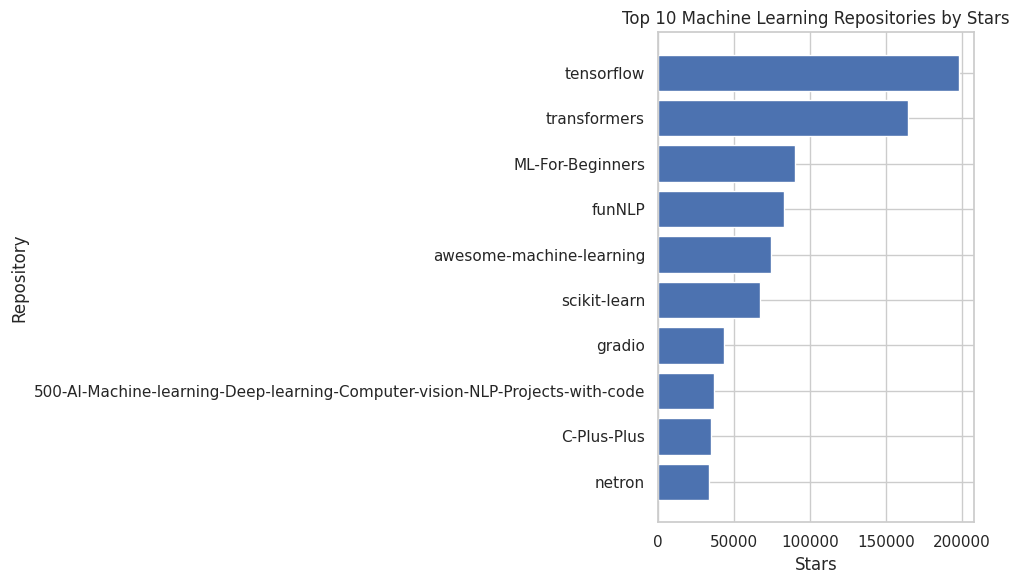

In [14]:
sns.set_theme(style="whitegrid")

# Chart 1: Top repositories by stars
top10 = df.nlargest(10, "stars").sort_values("stars")

plt.figure(figsize=(10, 6))
plt.barh(top10["name"], top10["stars"])
plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Machine Learning Repositories by Stars")
plt.tight_layout()
plt.show()


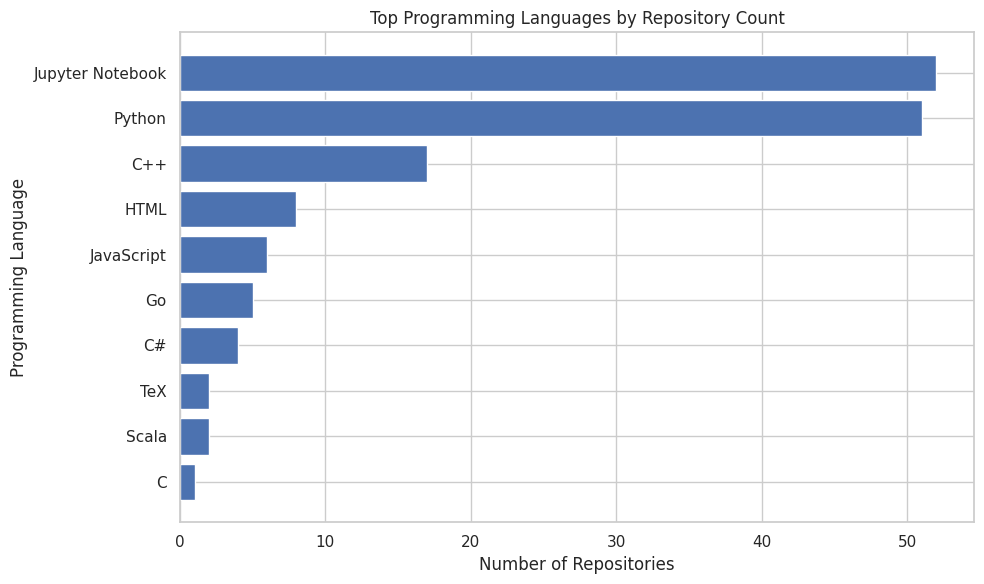

In [15]:
# Chart 2: Repository count by programming language
lang_counts = (
    df[df["language"] != "Unknown"]["language"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(lang_counts.index, lang_counts.values)
plt.xlabel("Number of Repositories")
plt.ylabel("Programming Language")
plt.title("Top Programming Languages by Repository Count")
plt.tight_layout()
plt.show()


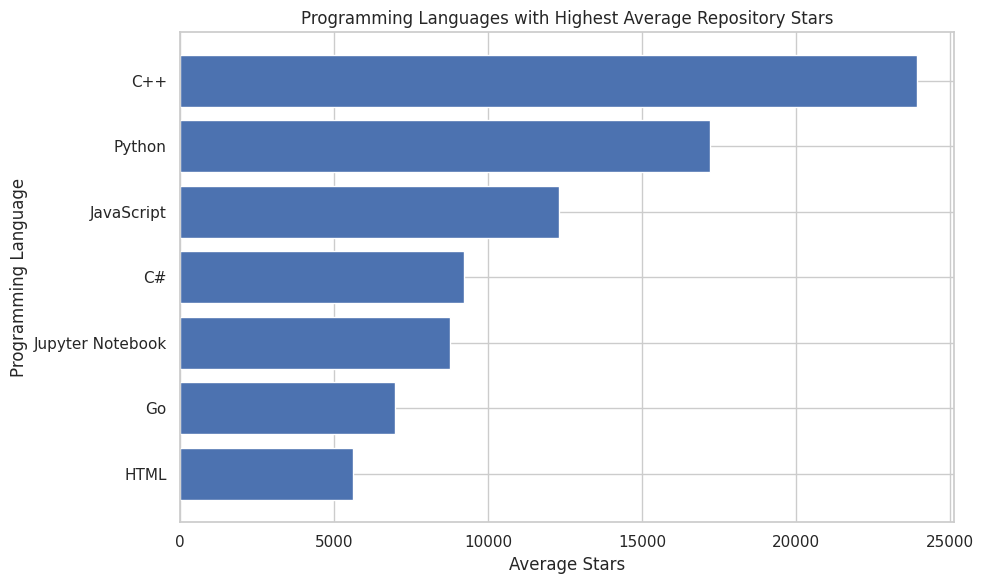

In [16]:
# Chart 3: Average stars by programming language
avg_stars = (
    df[df["language"] != "Unknown"]
    .groupby("language")
    .agg(repository_count=("repo_id", "count"),
         average_stars=("stars", "mean"))
    .query("repository_count >= 3")
    .sort_values("average_stars", ascending=False)
    .head(10)
    .sort_values("average_stars")
)

plt.figure(figsize=(10, 6))
plt.barh(avg_stars.index, avg_stars["average_stars"])
plt.xlabel("Average Stars")
plt.ylabel("Programming Language")
plt.title("Programming Languages with Highest Average Repository Stars")
plt.tight_layout()
plt.show()


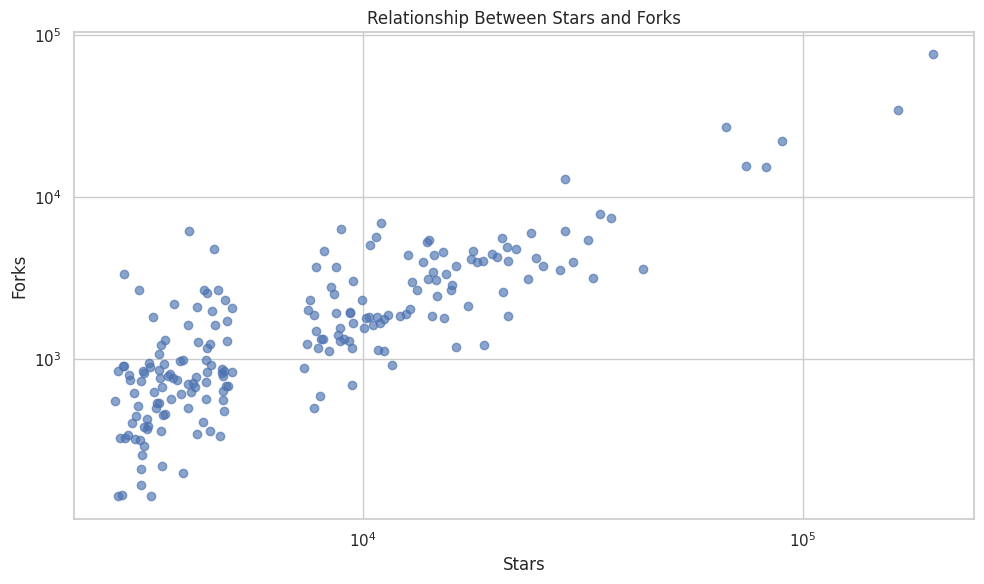

In [17]:
# Chart 4: Stars vs Forks
plt.figure(figsize=(10, 6))
plt.scatter(df["stars"], df["forks"], alpha=0.65)
plt.xlabel("Stars")
plt.ylabel("Forks")
plt.title("Relationship Between Stars and Forks")
plt.xscale("symlog")
plt.yscale("symlog")
plt.tight_layout()
plt.show()


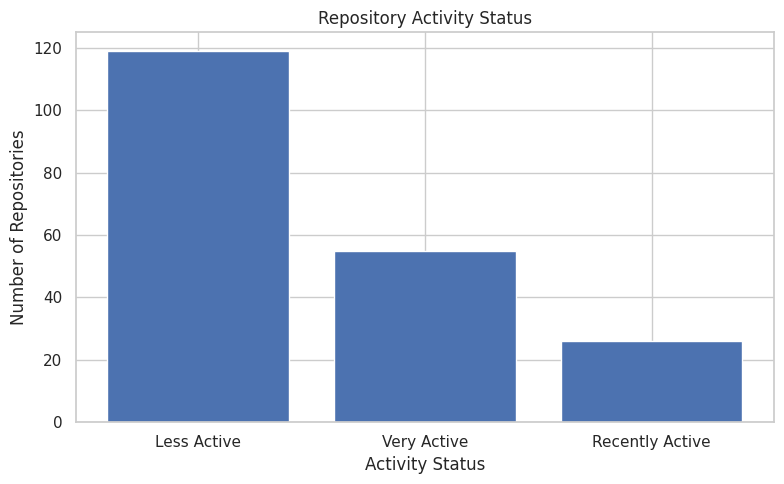

In [18]:
# Chart 5: Repository activity
activity_counts = df["activity_status"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(activity_counts.index, activity_counts.values)
plt.xlabel("Activity Status")
plt.ylabel("Number of Repositories")
plt.title("Repository Activity Status")
plt.tight_layout()
plt.show()


## 9. Automatic Insight Summary

This section turns the analysis into short, data-driven statements.


In [19]:
top_repo = df.loc[df["stars"].idxmax()]
top_language_count = (
    df[df["language"] != "Unknown"]["language"].value_counts().idxmax()
)
top_language_count_n = (
    df[df["language"] != "Unknown"]["language"].value_counts().max()
)

most_forked = df.loc[df["forks"].idxmax()]

corr = df[["stars", "forks"]].corr().loc["stars", "forks"]

active_share = (
    (df["activity_status"].isin(["Very Active", "Recently Active"])).mean() * 100
)

print("KEY INSIGHTS")
print("-" * 60)
print(f"1. Most-starred repository in the collected dataset: "
      f"{top_repo['full_name']} ({int(top_repo['stars']):,} stars).")
print(f"2. Most common programming language: "
      f"{top_language_count} ({int(top_language_count_n)} repositories).")
print(f"3. Most-forked repository: "
      f"{most_forked['full_name']} ({int(most_forked['forks']):,} forks).")
print(f"4. Correlation between stars and forks: {corr:.2f}.")
print(f"5. {active_share:.1f}% of repositories are either Very Active or Recently Active.")


KEY INSIGHTS
------------------------------------------------------------
1. Most-starred repository in the collected dataset: tensorflow/tensorflow (198,067 stars).
2. Most common programming language: Jupyter Notebook (52 repositories).
3. Most-forked repository: tensorflow/tensorflow (76,200 forks).
4. Correlation between stars and forks: 0.93.
5. 40.5% of repositories are either Very Active or Recently Active.


## 10. Responsible Use / Ethics Reflection

The dataset comes from public GitHub repository metadata. Public availability does not automatically mean that data can be used without responsibility.

For this project:
- We analyze repository-level public metadata rather than private user information.
- We keep the analysis focused on technical/project patterns.
- We should not make personal judgments about individual developers based on repository statistics.
- API usage should respect GitHub's terms, authentication requirements, and rate limits.
- Results should be interpreted as a sample collected at a specific time, not as a permanent ranking of the entire GitHub ecosystem.
- Repository popularity can be influenced by factors such as project age, organization size, community exposure, and external promotion.


## 11. Export project files from Colab

The next cell creates a small project package containing:
- cleaned CSV
- SQLite database
- SQL queries
- README


In [20]:
# Save SQL queries as a .sql file
sql_text = r'''
-- Q1: Top 10 repositories by stars
SELECT name, full_name, language, stars, forks, open_issues, html_url
FROM repositories
ORDER BY stars DESC
LIMIT 10;

-- Q2: Most popular programming languages by repository count
SELECT language, COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars,
       SUM(stars) AS total_stars
FROM repositories
WHERE language <> 'Unknown'
GROUP BY language
ORDER BY repository_count DESC
LIMIT 15;

-- Q3: Languages with highest average popularity
SELECT language, COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars
FROM repositories
WHERE language <> 'Unknown'
GROUP BY language
HAVING COUNT(*) >= 3
ORDER BY average_stars DESC
LIMIT 10;

-- Q4: Most forked repositories
SELECT name, full_name, language, stars, forks
FROM repositories
ORDER BY forks DESC
LIMIT 10;

-- Q5: Most active repositories
SELECT name, full_name, language, stars, forks,
       days_since_push, activity_status
FROM repositories
ORDER BY days_since_push ASC
LIMIT 10;

-- Q6: Archived vs non-archived
SELECT is_archived, COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars
FROM repositories
GROUP BY is_archived;

-- Q7: Average popularity by activity status
SELECT activity_status, COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars,
       ROUND(AVG(forks), 2) AS average_forks
FROM repositories
GROUP BY activity_status
ORDER BY average_stars DESC;
'''

with open("github_analysis_queries.sql", "w", encoding="utf-8") as f:
    f.write(sql_text)

readme = f'''# DECI GitHub Machine Learning Repository Analytics

## Project Overview
An end-to-end data analytics project using real public GitHub repository metadata.

## Workflow
GitHub API → Pandas Cleaning → CSV → SQLite → SQL Analysis → Python Visualizations → Insights → GitHub → Ethics

## Tools
- Python
- Requests
- Pandas
- SQLite
- SQL
- Matplotlib
- Seaborn
- Git/GitHub
- Google Colab

## Dataset
The dataset is collected from the GitHub REST API using a Machine Learning repository search.

## Main Questions
1. Which repositories are the most popular by stars?
2. Which programming languages appear most frequently?
3. Which languages have the highest average repository popularity?
4. Which repositories are most forked?
5. Which repositories are most recently active?
6. How do archived and non-archived repositories compare?
7. What is the relationship between stars and forks?

## Responsible Use
Only public repository metadata is analyzed. The results represent the collected sample at the time of extraction and should not be treated as a permanent ranking of GitHub.

## How to Run
Open the `.ipynb` file in Google Colab and run all cells from top to bottom.
'''

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("Project export files prepared.")


Project export files prepared.


In [21]:
# Download the main deliverables in Colab
from google.colab import files

print("Files ready:")
print("- github_ml_repositories_clean.csv")
print("- github_ml_analysis.sqlite")
print("- github_analysis_queries.sql")
print("- README.md")


Files ready:
- github_ml_repositories_clean.csv
- github_ml_analysis.sqlite
- github_analysis_queries.sql
- README.md
